# EDA Part 1 - Distributions & Outliers

#### Week 2 - Day 4

In this notebook, we will cover:

1. **Loading** a provided **real dataset** and produce a **histogram** for each numeric variable.
2.  Produce a **box plot** for the key numeric variables and identify any **outliers** visually.
3. Apply the **IQR** method in code to flag **outliers** in at least one column and decide (with justification) how to handle them.
4. Produce a **count plot** for each **categorical variable** and note any class imbalance.
   > Note: Words written in bold represents key topics that were studied and covered during the day.

### Step 1 - Loading real dataset (titanic dataset - ML from Disaster) & histogram:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


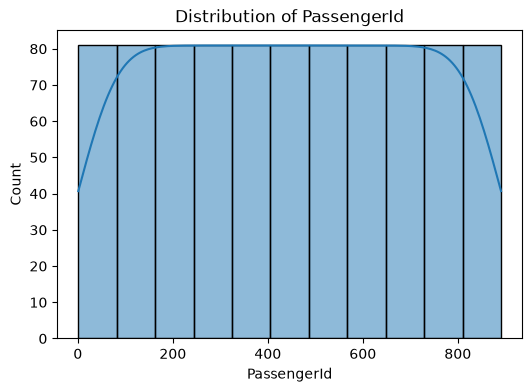

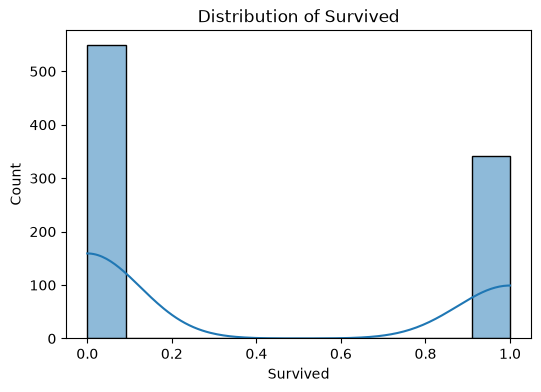

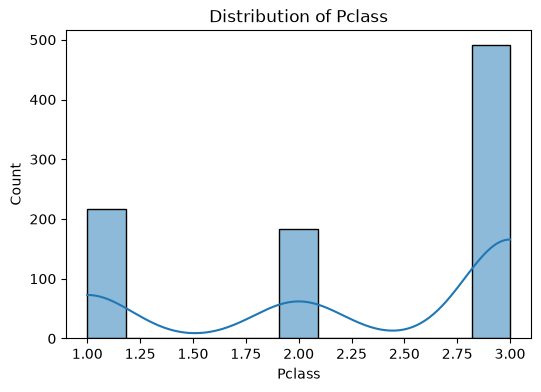

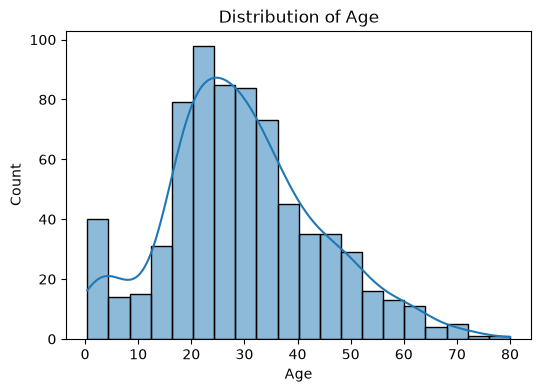

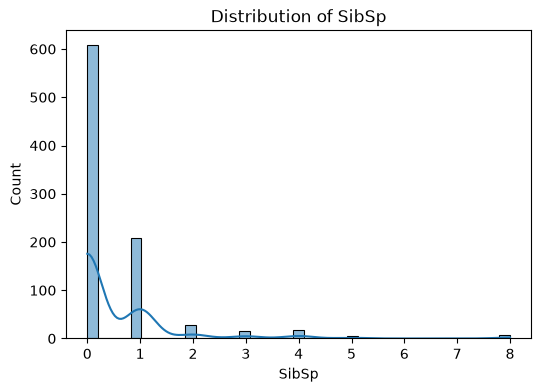

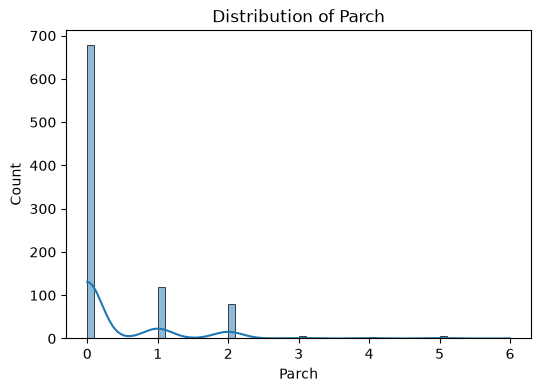

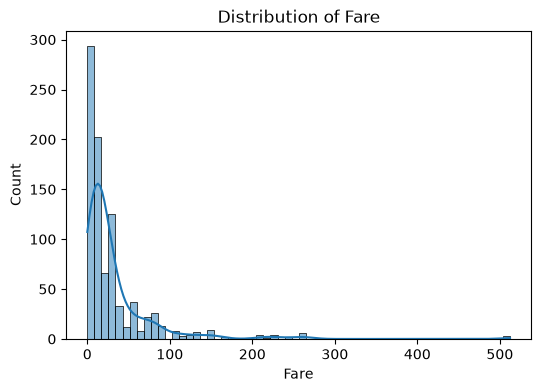

In [8]:
numeric_cols = df.select_dtypes(include="number").columns  # 1. select_dtypes: filters columns by their data types.
                                                           # 2. include="number": means we only want numeric columns.
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)                #3. kde=True: means overlays a smooth curve on top of the histogram.
    plt.title(f"Distribution of {col}")
    plt.show()

### Step 2 - Box plot for numeric variables & identify any outliers visually

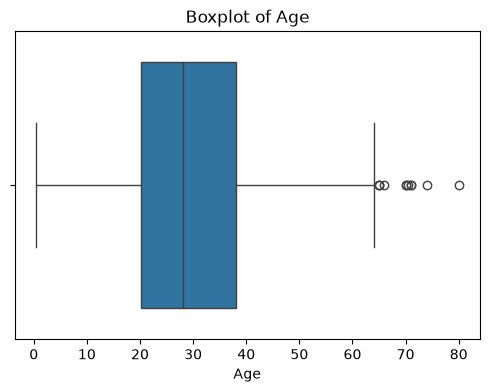

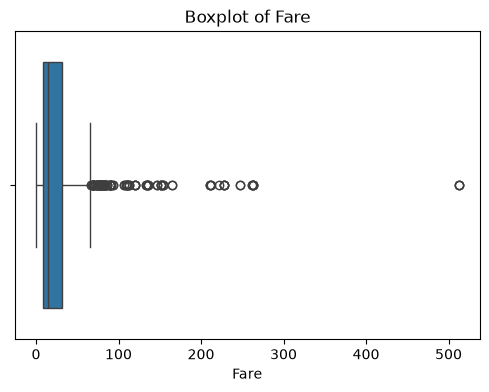

In [9]:
key_numeric_cols = ["Age", "Fare"]

for col in key_numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

> From the boxplot I notice the "Fare" column has many **points beyond the whisker**, these are candidates for being **outliers**.

### Step 3 - Apply the IQR method in code to flag outliers & how to handle them.

In [14]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR  

# Any value below lower bound or above upper bound is outlier.

outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]
print(f"Number of outliers in Fare = {len(outliers)}")
outliers[["Fare"]].describe()

Number of outliers in Fare = 116


,Fare
count,116.000000
mean,128.291629
std,84.636908
min,66.600000
25%,78.189600
50%,90.000000
75%,147.778100
max,512.329200


> **I decided:** I Will not remove them, because the values are legitimate. So, it is not data errors.

#### Step 4 - Count plot for categorical variable: 

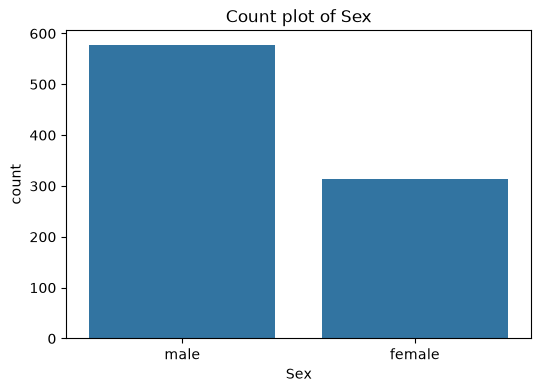

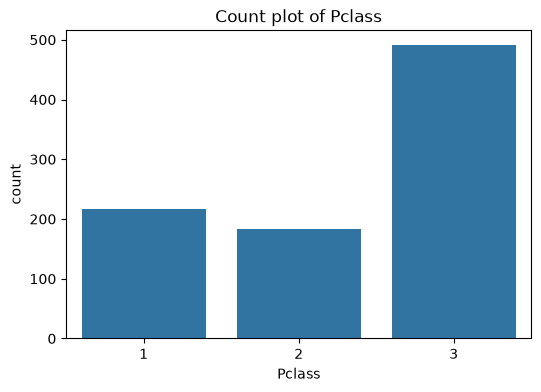

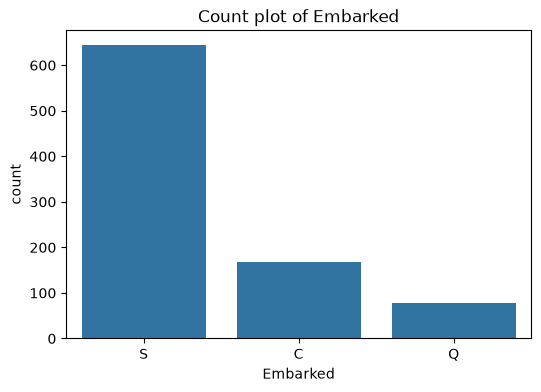

In [15]:
categorical_cols = ["Sex", "Pclass", "Embarked"]  # These are categorical columns, meaning they have a limited set of repeated values(not continuous numbers).

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count plot of {col}")
    plt.show()

> **Class imbalance:** the Pclass column has far more third-class passengers than first or second class. 

**Note: Every cell of above is explaied by markdown cell or by comments.**